In [3]:
from functions import *
%matplotlib widget
import matplotlib.pyplot as plt

def get_QLF(z, dM, bin_num = 100, sig_lnMstar = 0.7, sig_lnX = [3.5,2.2]):

    qlf = QLF(z, bin_num)
    qlf.LumBins = np.linspace(8.5, 16.5, bin_num)
    qlf.get_dNdlnMstar(sig_lnMstar)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(sig_lnX)
    
    return qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))

In [4]:
plt.close('all')
z = 2

# min_list = []
# max_list = []
# for z in [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]:
#     xm, ym = get_QLF(z = z, dM = 0.4, obscured = 0.6)
#     plt.plot(xm,ym,label = str(z))
#     x, y , yerr = grab_obs(z)
#     min_list.append(min(x))
#     max_list.append(max(x))
#     plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5)
# print(max(max_list),min(min_list))

xm, ym = get_QLF(z = z, dM = 0.4, sig_lnX = [3.5,2.2], sig_lnMstar = .7)
plt.plot(xm,ym,label = str(z))
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5)

plt.axis([8.5,16.5,-10,0])
plt.xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$')
plt.ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$')
plt.legend()
plt.show()


FigureCanvasNbAgg()

MCMC set-ups:

First cell should not change as variables change.

Once run just minimize to make things look nicer.

In [18]:
import emcee
import corner
import scipy.optimize as op
import timeit
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
bin_num = 100
sig_lnMstar = 0.7

qlf_00 = QLF(0.0, bin_num)
qlf_01 = QLF(0.1, bin_num)
qlf_02 = QLF(0.2, bin_num)
qlf_05 = QLF(0.5, bin_num)    
qlf_10 = QLF(1.0, bin_num)
qlf_15 = QLF(1.5, bin_num)
qlf_20 = QLF(2.0, bin_num)
qlf_25 = QLF(2.5, bin_num)
qlf_30 = QLF(3.0, bin_num)
qlf_35 = QLF(3.5, bin_num)
qlf_40 = QLF(4.0, bin_num)
qlf_45 = QLF(4.5, bin_num)
qlf_50 = QLF(5.0, bin_num)
qlf_55 = QLF(5.5, bin_num)
qlf_60 = QLF(6.0, bin_num)

qlf_list = [qlf_00, qlf_01, qlf_02, qlf_05, qlf_10, qlf_15, qlf_20, qlf_25, qlf_30, qlf_35, qlf_40, qlf_45, qlf_50, qlf_55, qlf_60]

for i in qlf_list:
    i.LumBins = np.linspace(8.5, 16.5, bin_num)
    i.get_dNdlnMstar(sig_lnMstar)
    
xt_tot = []
yt_tot = []
yerr_tot = []
z_tot = []

for z in zlist:
    x, y, yerr = grab_obs(z)
    xt_tot.extend(x)
    yt_tot.extend(y)
    yerr_tot.extend(yerr)
    for j in range(len(x)):
        z_tot.append(z)

MCMC stuff start by just freeing dM.

.

.

.

.

In [19]:
def get_QLF_mcmc(dM, i, sig_lnMstar = 0.7, sig_lnX = [3.5,2.2]):
    i.get_SMBM(dM)
    i.get_dNdlnL(sig_lnX)
    return i.LumBins, np.log10(i.dNdlnL * np.log(10))

def model_func_op(x, p, i):
    xm, ym = get_QLF_mcmc(p, i)
    y = np.interp(x, xm, ym)
    return y

def lnchi2_op(p, i, x, y, err): #lnlike
    chi2 = np.sum((model_func_op(x, p, i) - y) ** 2 / (err**2)) / (len(x)-1)
    return -chi2

def lnprior(p):
    if 0.0 < p <= 3.0:
        return 0.0
    return -np.inf

def lnprob(p, z, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, z, x, y, err)
    return -np.inf

def lnchi2(p, z, x, y, err): #lnlike
    chi2 = np.sum((model_func(x, p, z) - y) ** 2 / (err ** 2)) / (len(x)-1)
    return -chi2

def model_func(x, p, z):
    y = []
    z = np.array(z)
    for zs, i in zip(zlist, qlf_list):
        i.get_SMBM(p)
        i.get_dNdlnL(lnxsigs = [3.5,2.2])
        xm, ym = i.LumBins, np.log10(i.dNdlnL * np.log(10))
        where = (z == zs)  
        y.extend(np.interp(np.array(x)[where], xm, ym))
    return y

p = 1.5
nll = lambda *args: -lnchi2_op(*args)
results = []
bond = ((0.01, 3.0))

for i, z in zip(qlf_list, zlist):
    xt, yt, yerr = np.array(grab_obs(z))
    results.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'L-BFGS-B', bounds = ((0.0,3.0),))["x"])

pinit = np.sum(results)/len(results)
print(pinit)

ndim = 1
cornlabels = ['dM']

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:128: RuntimeWarning: divide by zero encountered in true_divide
  slope2 = (mbh2 - mbh1) / (mstar2 - mstar1)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: divide by zero encountered in double_scalars
  if sys.path[0] == '':
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:663: RuntimeWarning: invalid value encountered in double_scalars
  grad[k] = (f(*((xk + d,) + args)) - f0) / d[k]
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:132: RuntimeWarning: invalid value encountered in less_equal
  self.early = (self.StellBins <= self.mass_cuts[0])
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:133: RuntimeWarning: invalid value encountered in greater
  self.growth = ((self.StellBins > self.mass_cuts[0]) & (self.StellBins < self.mass_cu

0.1


Now defining stuff for MCMC with two free paramets: dM and sig_lnX for the post-disk phase.

.

.

.

.

In [7]:
def get_QLF_mcmc(dM, sigpost, i, sig_lnMstar = 0.7, sigpre = 3.5):
    sig_lnX = [sigpre, sigpost]
    i.get_SMBM(dM)
    i.get_dNdlnL(sig_lnX)
    return i.LumBins, np.log10(i.dNdlnL * np.log(10))

def model_func_op(x, p, i):
    xm, ym = get_QLF_mcmc(p[0], p[1], i)
    y = np.interp(x, xm, ym)
    return y

def lnchi2_op(p, i, x, y, err): #lnlike
    chi2 = np.sum((model_func_op(x, p, i) - y) ** 2 / (err**2)) / (len(x)-1)
    return -chi2

def lnprior(p):
    if 0.0 < p[0] <= 3.0 and p[1] > 0.0:
        return 0.0
    return -np.inf

def lnprob(p, z, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, z, x, y, err)
    return -np.inf

def lnchi2(p, z, x, y, err): #lnlike
    chi2 = np.sum((model_func(x, p, z) - y) ** 2 / (err ** 2)) / (len(x)-1)
    return -chi2

def model_func(x, p, z):
    y = []
    z = np.array(z)
    for zs, i in zip(zlist, qlf_list):
        i.get_SMBM(p[0])
        i.get_dNdlnL(lnxsigs = [3.5, p[1]])
        xm, ym = i.LumBins, np.log10(i.dNdlnL * np.log(10))
        where = (z == zs)  
        y.extend(np.interp(np.array(x)[where], xm, ym))
    return y

p = [1.5, 2.5]
nll = lambda *args: -lnchi2_op(*args)
results = []
bond = ((0.01, 3.0), (0.0,5.0))

for i, z in zip(qlf_list, zlist):
    xt, yt, yerr = np.array(grab_obs(z))
    results.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'L-BFGS-B', bounds = bond)["x"])

pinit = np.sum(np.array(results), axis=0) / len(results)
print(pinit)

ndim = 2
cornlabels = ['dM', 'sig_lnX-postdisk']

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:215: RuntimeWarning: divide by zero encountered in double_scalars
  y = ( A/np.sqrt(2.0 * np.pi * sig**2.0) ) * np.exp( -(x - mu)**2.0 / (2.0 * sig**2) )
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:215: RuntimeWarning: divide by zero encountered in true_divide
  y = ( A/np.sqrt(2.0 * np.pi * sig**2.0) ) * np.exp( -(x - mu)**2.0 / (2.0 * sig**2) )
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:215: RuntimeWarning: invalid value encountered in multiply
  y = ( A/np.sqrt(2.0 * np.pi * sig**2.0) ) * np.exp( -(x - mu)**2.0 / (2.0 * sig**2) )
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: divide by zero encountered in double_scalars
  del sys.path[0]
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:663: RuntimeWarning: invalid value

[0.78942627 2.82278212]


Next we can actually run the sampler for any number of free parameters we want. Assuming we have defined the proper equations above already.

They all use the same data just different lnprob, ndim, etc.

In [20]:
nwalkers, steps, runs, threads = 10, 200, 5, 1
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))

In [6]:
pos = [pinit + .3*np.random.randn(ndim) for i in range(nwalkers)]
%time sampler.run_mcmc(pos, steps)
print('Done.')

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/ensemble.py:335: RuntimeWarning: invalid value encountered in subtract
  lnpdiff = (self.dim - 1.) * np.log(zz) + newlnprob - lnprob0
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/ensemble.py:336: RuntimeWarning: invalid value encountered in greater
  accept = (lnpdiff > np.log(self._random.rand(len(lnpdiff))))


CPU times: user 2min 42s, sys: 1.03 s, total: 2min 43s
Wall time: 2min 45s


(array([[-0.33943649],
        [ 0.15088452],
        [ 0.10478252],
        [ 0.0826615 ],
        [ 0.09283936],
        [-0.40757876],
        [ 0.12483461],
        [ 0.12292307],
        [ 0.0810171 ],
        [ 0.19838779],
        [ 0.1511862 ],
        [ 0.11096763],
        [ 0.1532743 ],
        [ 0.08700008],
        [-0.45751097],
        [-0.35900146],
        [ 0.08140978],
        [-0.39549288],
        [ 0.10112491],
        [ 0.15056661],
        [ 0.12535669],
        [ 0.08153923],
        [ 0.1733552 ],
        [ 0.1010995 ],
        [ 0.08104993],
        [ 0.08100025],
        [-0.30669455],
        [ 0.08252065],
        [ 0.08220049],
        [-0.2532756 ],
        [ 0.20575223],
        [ 0.08446838],
        [ 0.15050347],
        [ 0.31309635],
        [ 0.08059237],
        [ 0.10856273],
        [ 0.16007072],
        [ 0.15142943],
        [ 0.22068948],
        [ 0.1078851 ]]),
 array([        -inf, -13.1594066 , -14.29742257, -13.12766022,
        -15.48

In [36]:
pos = sampler.chain[:,-1,:]
%time sampler.run_mcmc(pos, steps)
print('Done.')

emcee: Exception while calling your likelihood function:
  params: [0.32223776]
  args: (array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 

Traceback (most recent call last):
  File "/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/ensemble.py", line 519, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "<ipython-input-19-c0cc749e4893>", line 23, in lnprob
    return lp + lnchi2(p, z, x, y, err)
  File "<ipython-input-19-c0cc749e4893>", line 27, in lnchi2
    chi2 = np.sum((model_func(x, p, z) - y) ** 2 / (err ** 2)) / (len(x)-1)
  File "<ipython-input-19-c0cc749e4893>", line 35, in model_func
    i.get_dNdlnL(lnxsigs = [3.5,2.2])
  File "/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py", line 229, in get_dNdlnL
    lnMdot_mu_msig = np.apply_along_axis(self.get_Mdotbh, 1, vals, lnxsigs)
  File "/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/numpy/lib/shape_base.py", line 403, in apply_along_axis
    buff[ind] = asanyarray(func1d(inarr_view[ind], *args, **kwargs))
  File "/Users/megantillman/anaconda3/envs/astroconda/lib

KeyboardInterrupt: 

Done.


In [13]:
#print(sampler.chain[:,100:,:])
for i in range(100,200):
    for j in sampler.chain[:,i,0]:
        pass
print(sampler.chain[:,0,0]) ###first index is walker, second is step, third is variable
samples = sampler.chain[:,10:,:].reshape((-1,ndim))
print(samples)
fig = corner.corner(samples, labels = cornlabels)

print(sampler.acceptance_fraction)

NameError: name 'sampler' is not defined

In [29]:
vals = np.loadtxt("Quest-emcee/output/dM-chain-v1.0_n200_s1000_t12.dat")
fig = corner.corner(vals[50:].reshape((-1,1)),labels=['dM'])

FigureCanvasNbAgg()

In [44]:
pos = [[.1,.1] + .5*np.random.randn(2) for i in range(nwalkers)]
pos = np.array(pos)
pos[(pos <= 0.0)] = 0.01
print(pos)

[[0.76815375 0.19190358]
 [0.01       0.01      ]
 [0.01       0.7086071 ]
 [0.49327688 0.03363721]
 [0.01       0.28645398]
 [0.01       0.55059225]
 [0.12684278 1.05989386]
 [0.01       0.67842144]
 [0.20661394 0.01      ]
 [0.04432094 0.24779624]]


Reference code I may want to use later is below here.

.

.

.

.

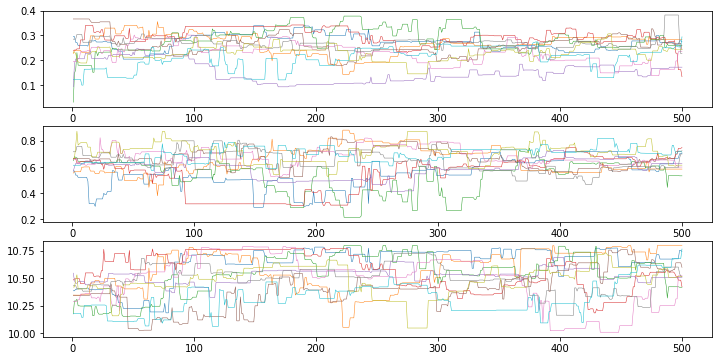

In [52]:
import matplotlib.gridspec as gridspec

gs = gridspec.GridSpec(3, 1)
fig = plt.figure(figsize=(12,6))

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

for w in sampler1.chain[:,:,:]:
    dmy = []
    oby = []
    mmidy = []
    for y in w:
        dmy.append(y[0])
        oby.append(y[1])
        mmidy.append(y[2])
    x = np.linspace(1,steps,steps)
    ax0.plot(x,dmy,linewidth=0.5)
    ax1.plot(x,oby,linewidth=0.5)
    ax2.plot(x,mmidy,linewidth=0.5)

In [92]:
samples_2fit_multicore = sampler_2fit_multicore.chain[:,2:,:].reshape((-1,ndim))
# print(sampler_2fit_multicore.get_autocorr_time(c=1, low = 10))
# print(sampler_2fit_multicore.acceptance_fraction)


f = open("output/chain-v1.0_n"+str(nwalkers)+"_s"+str(steps)+".dat","w")
f.write('###  dM          obscured fraction \n')
f.write('###  nwalkers = '+str(nwalkers)+'   steps = '+str(steps)+'\n')
f.write('###  **each walker is seperated by three pound signs** \n')
for i in sampler_2fit_multicore.chain[:,:,:]:
    for j in i:
        f.write(str(j[0])+' '+str(j[1])+'\n')
    f.write('### \n')
f.close()

vals = np.loadtxt("output/chain-v1.0_n"+str(nwalkers)+"_s"+str(steps)+".dat")
print(vals)
fig = corner.corner(vals,labels=['dM','ob %'])

[[0.24850507 0.66186208]
 [0.20734097 0.6558523 ]
 [0.20734097 0.6558523 ]
 ...
 [0.15361979 0.73434169]
 [0.13935652 0.73341259]
 [0.14195298 0.73548165]]


FigureCanvasNbAgg()

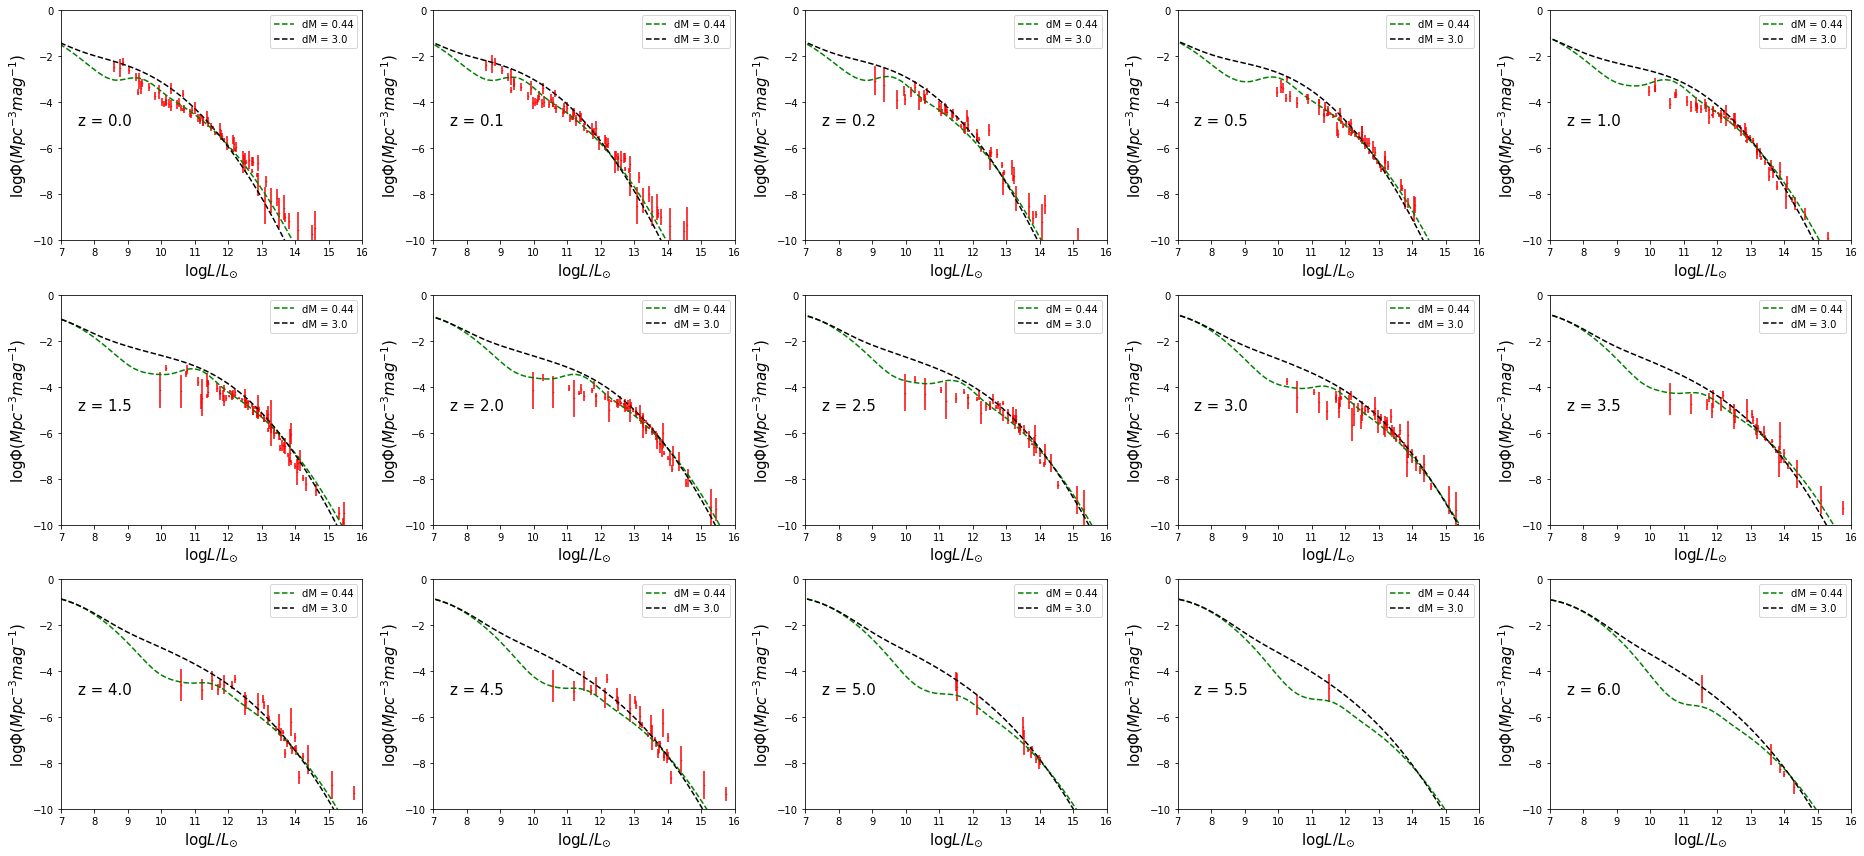

In [14]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(26,12))
gs = gridspec.GridSpec(3, 5)
fs = 15
mcmc_dM_l = [0.44, 3.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):

    xt, yt , yerr = np.array(grab_obs(z))   
    ax = fig.add_subplot(gs[i, j])
    for dM,c in zip(mcmc_dM_l,['g','k']):
        xm, ym = get_QLF(z, bin_num, dM = dM, obscured = .75, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35])
        ax.plot(xm,ym,label='dM = '+str(dM),linestyle='dashed',color=c)
    ax.set_xlabel(r'$\log L/L_{\odot}$',fontsize=fs)
    ax.set_ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$',fontsize=fs)
    ax.text(7.5,-5,'z = '+str(z),fontsize=fs)
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
    ax.axis([7,16,-10,0])
    ax.legend()
        
plt.tight_layout()
plt.savefig('plots/MCMC_dM_QLF_v1.0.pdf')
